# Library

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting


# Analytical

In [ ]:
# Parameters
mu = 0.10
r = 0.03
sigma = 0.20
gamma = 1.0
T = 1.0

Analytic optimal pi* = 1.7499999999999998


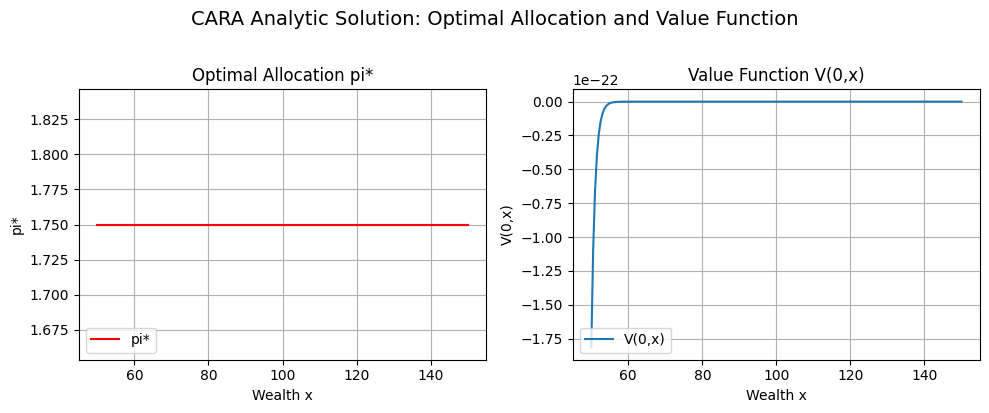

In [ ]:
pi_star_analytic = (mu - r) / (gamma * sigma**2)
print("Analytic optimal pi* =", pi_star_analytic)

def V_analytic(t, x):
    A = (mu - r)**2 / (2 * gamma * sigma**2)
    return -np.exp(-gamma*x - A*(T - t))

x_vals = np.linspace(50, 150, 200)
V0 = V_analytic(0, x_vals)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(x_vals, np.ones_like(x_vals) * pi_star_analytic, label="pi*",color='red')
axes[0].set_xlabel("Wealth x")
axes[0].set_ylabel("pi*")
axes[0].set_title("Optimal Allocation pi*")
axes[0].legend(loc='lower left')
axes[0].grid(True)
axes[1].plot(x_vals, V0, label="V(0,x)")
axes[1].set_xlabel("Wealth x")
axes[1].set_ylabel("V(0,x)")
axes[1].set_title("Value Function V(0,x)")
axes[1].legend(loc='lower left')
axes[1].grid(True)
fig.suptitle("CARA Analytic Solution: Optimal Allocation and Value Function", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

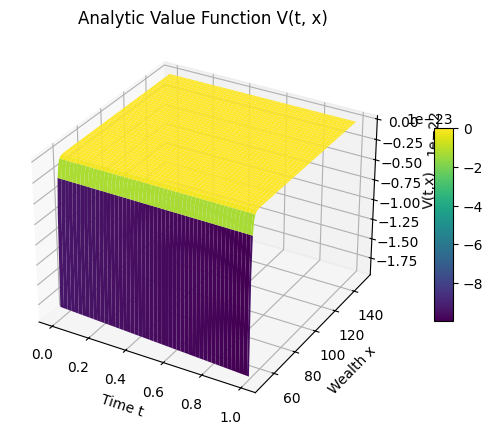

In [ ]:
t_vals = np.linspace(0, T, 100)
x_vals = np.linspace(50, 150, 100)
T_grid, X_grid = np.meshgrid(t_vals, x_vals)
V_grid = V_analytic(T_grid, X_grid)

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_grid, X_grid, V_grid, cmap='viridis', edgecolor='none')
ax.set_xlabel("Time t")
ax.set_ylabel("Wealth x")
ax.set_zlabel("V(t,x)")
ax.set_title("Analytic Value Function V(t, x)")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

# PINN

In [ ]:
x_min = 0 #50.0
x_max = 500 #150.0

def grad(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),create_graph=True, retain_graph=True)[0]

class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1, nlayers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        for _ in range(nlayers - 1):
            layers.append(nn.Tanh())
            layers.append(nn.Linear(hidden, hidden))
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, t, x):
        tt = t / T
        xx = (x - (x_min + x_max) / 2.0) / (x_max - x_min)
        inp = torch.cat([tt, xx], dim=1)
        return self.net(inp)

V_net = MLP()
pi_net = MLP()

N_f = 5000 #3000
N_T = 300
N_b = 200
lr = 5e-4
epochs = 6000
optimizer = optim.Adam(list(V_net.parameters()) + list(pi_net.parameters()),lr=lr)
w_pde = 1.0
w_term = 200.0
w_bc = 10.0
w_pi_reg = 1e-4 #1e-3
x_T = torch.linspace(x_min, x_max, N_T).unsqueeze(1)
t_T = torch.ones_like(x_T) * T
loss_history = []

for it in range(epochs):
    V_net.train()
    pi_net.train()

    optimizer.zero_grad()

    # interior points
    t_f = torch.rand(N_f, 1) * T
    x_f = x_min + (x_max - x_min) * torch.rand(N_f, 1)
    t_f.requires_grad_(True)
    x_f.requires_grad_(True)

    # forward pass
    V_f = V_net(t_f, x_f)
    pi_f = pi_net(t_f, x_f)

    # derivatives
    V_t = grad(V_f, t_f)
    V_x = grad(V_f, x_f)
    V_xx = grad(V_x, x_f)

    # PDE
    pde_res = V_t + r * x_f * V_x + pi_f * (mu - r) * V_x \
              + 0.5 * (pi_f**2) * sigma**2 * V_xx
    loss_pde = torch.mean(pde_res**2)

    # terminal
    x_Tb = x_T.clone().detach().requires_grad_(True)
    t_Tb = t_T.clone().detach().requires_grad_(True)
    V_T_pred = V_net(t_Tb, x_Tb)
    V_T_true = -torch.exp(-gamma * x_Tb)
    loss_term = torch.mean((V_T_pred - V_T_true)**2)

    # boundary soft anchoring
    t_b = torch.rand(N_b, 1) * T
    x_b_left = torch.ones_like(t_b) * x_min
    x_b_right = torch.ones_like(t_b) * x_max
    V_b_left = V_net(t_b, x_b_left)
    V_b_right = V_net(t_b, x_b_right)
    V_b_left_target  = -torch.exp(-gamma * x_b_left)
    V_b_right_target = -torch.exp(-gamma * x_b_right)

    loss_bc = torch.mean((V_b_left  - V_b_left_target )**2) + \
              torch.mean((V_b_right - V_b_right_target)**2)

    # pi regularizer
    loss_pi_reg = torch.mean((pi_f - pi_star_analytic)**2)

    # total loss
    loss = (w_pde * loss_pde +w_term * loss_term + w_bc * loss_bc + w_pi_reg * loss_pi_reg)
    #loss = (w_pde * loss_pde +w_term * loss_term + w_pi_reg * loss_pi_reg)

    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (it+1) % 200 == 0 or it == 0:
        # monitoring at (t=0,x=100)
        t_test = torch.tensor([[0.0]], requires_grad=True)
        x_test = torch.tensor([[100.0]], requires_grad=True)
        Vt = V_net(t_test, x_test)
        pit = pi_net(t_test, x_test)
        print(f"iter {it+1:5d} loss={loss.item():.3e} "
              f"pde={loss_pde.item():.3e} term={loss_term.item():.3e} "
              f"pi(0,100)={pit.item():.4f} " f"V(0,100)={Vt.item():.4f}")

iter     1 loss=1.039e+01 pde=6.541e-05 term=3.372e-03 pi(0,100)=0.0156 V(0,100)=-0.0451
iter   200 loss=2.913e+00 pde=4.111e-01 term=5.231e-03 pi(0,100)=0.0257 V(0,100)=-0.9392
iter   400 loss=1.975e+00 pde=4.140e-01 term=4.165e-03 pi(0,100)=0.5316 V(0,100)=-0.8366
iter   600 loss=1.709e+00 pde=3.734e-01 term=3.636e-03 pi(0,100)=1.7583 V(0,100)=-0.8284
iter   800 loss=1.402e+00 pde=3.149e-01 term=3.250e-03 pi(0,100)=1.4731 V(0,100)=-0.7597
iter  1000 loss=1.245e+00 pde=2.541e-01 term=3.010e-03 pi(0,100)=-4.3669 V(0,100)=-0.5451
iter  1200 loss=9.128e-01 pde=1.944e-01 term=2.769e-03 pi(0,100)=-7.2410 V(0,100)=-0.1736
iter  1400 loss=8.336e-01 pde=1.462e-01 term=2.552e-03 pi(0,100)=4.1280 V(0,100)=0.0795
iter  1600 loss=8.086e-01 pde=1.356e-01 term=2.252e-03 pi(0,100)=1.8231 V(0,100)=0.0985
iter  1800 loss=6.066e-01 pde=9.314e-02 term=2.097e-03 pi(0,100)=1.6890 V(0,100)=0.0586
iter  2000 loss=5.228e-01 pde=6.481e-02 term=1.818e-03 pi(0,100)=1.6433 V(0,100)=0.0306
iter  2200 loss=5.137e-

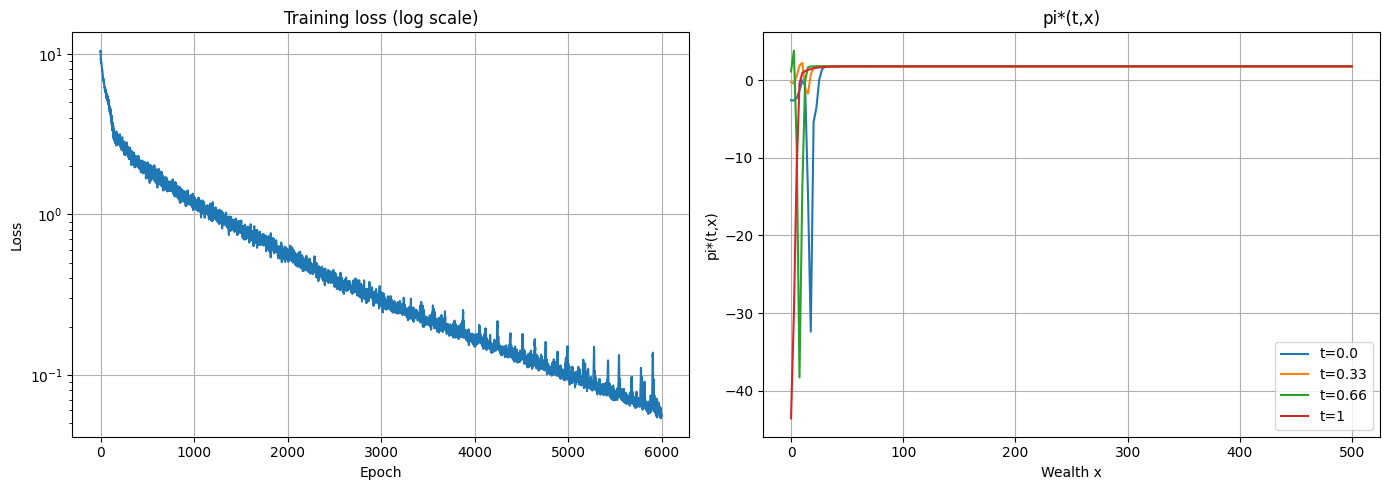

In [ ]:
x_grid = np.linspace(x_min, x_max, 200)
x_t = torch.tensor(x_grid.reshape(-1,1), dtype=torch.float32)


fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(loss_history)
axes[0].set_yscale('log')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss (log scale)")
axes[0].grid(True)

t_slices = [0.0, 0.33, 0.66,1]
for ts in t_slices:
    t_vec = torch.full_like(x_t, ts)
    with torch.no_grad():
        pi_ts = pi_net(t_vec, x_t).numpy().flatten()
    axes[1].plot(x_grid, pi_ts, label=f"t={ts}")

axes[1].set_xlabel("Wealth x")
axes[1].set_ylabel("pi*(t,x)")
axes[1].set_title("pi*(t,x)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

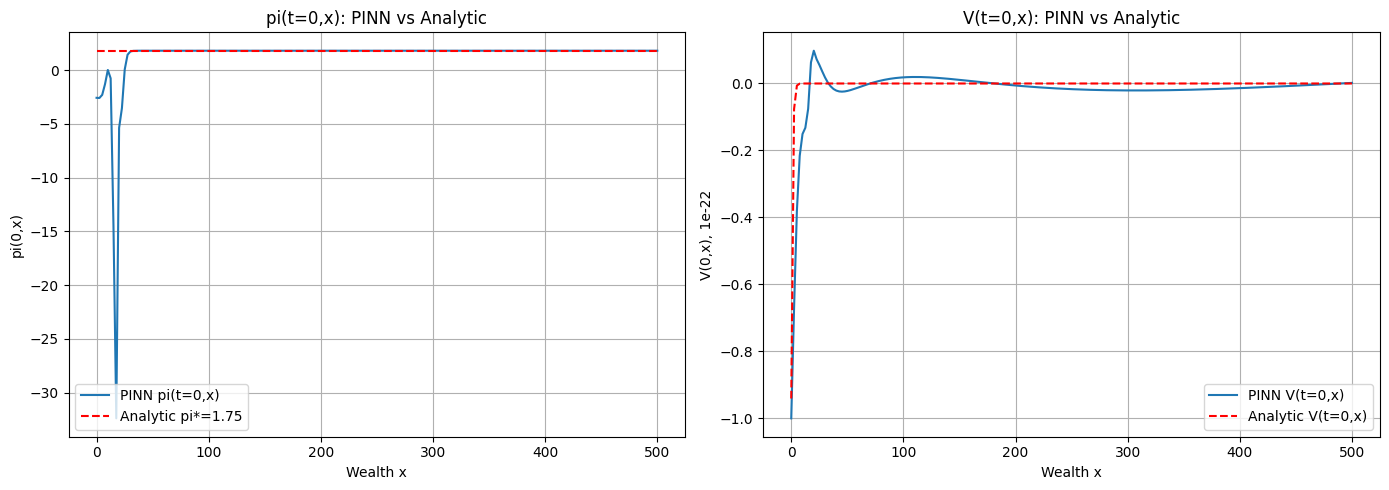

In [ ]:
t0 = torch.zeros_like(x_t)

with torch.no_grad():
    pi_pred = pi_net(t0, x_t).numpy().flatten()
    V_pred = V_net(t0, x_t).numpy().flatten()

V0_analytic = V_analytic(0, x_grid)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(x_grid, pi_pred, label="PINN pi(t=0,x)")
axes[0].hlines(pi_star_analytic, x_grid[0], x_grid[-1], colors="k", linestyles="--",color='red',label=f"Analytic pi*={pi_star_analytic:.2f}")
axes[0].set_xlabel("Wealth x")
axes[0].set_ylabel("pi(0,x)")
axes[0].set_title("pi(t=0,x): PINN vs Analytic")
axes[0].legend(loc='lower left')
axes[0].grid(True)

axes[1].plot(x_grid, V_pred, label="PINN V(t=0,x)")
axes[1].plot(x_grid, V0_analytic, "--", label="Analytic V(t=0,x)",color='red')
axes[1].set_xlabel("Wealth x")
axes[1].set_ylabel("V(0,x), 1e-22")
axes[1].set_title("V(t=0,x): PINN vs Analytic")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:

X0 = 100.0
t0 = 0.0

x0_torch = torch.tensor([[X0]], dtype=torch.float32, requires_grad=True)
t0_torch = torch.tensor([[t0]], dtype=torch.float32, requires_grad=True)

def V_analytic(t, x):
    A = (mu - r)**2 / (2 * gamma * sigma**2)
    return -np.exp(-gamma * x - A * (T - t))

def Vx_analytic(t, x):
    A = (mu - r)**2 / (2 * gamma * sigma**2)
    return -(-gamma) * np.exp(-gamma * x - A * (T - t))

def Vxx_analytic(t, x):
    A = (mu - r)**2 / (2 * gamma * sigma**2)
    return gamma**2 * np.exp(-gamma * x - A * (T - t))

def pi_analytic_func(t, x):
    return (mu - r) / (gamma * sigma**2)

V_pred = V_net(t0_torch, x0_torch)
Vx_pred = grad(V_pred, x0_torch)
Vxx_pred = grad(Vx_pred, x0_torch)
pi_pred = pi_net(t0_torch, x0_torch)
V_pred_np = V_pred.detach().cpu().numpy()[0,0]
Vx_pred_np = Vx_pred.detach().cpu().numpy()[0,0]
Vxx_pred_np = Vxx_pred.detach().cpu().numpy()[0,0]
pi_pred_np = pi_pred.detach().cpu().numpy()[0,0]

V_true = V_analytic(t0, X0)
Vx_true = Vx_analytic(t0, X0)
Vxx_true = Vxx_analytic(t0, X0)
pi_true = pi_analytic_func(t0, X0)

def abs_rel(pred, true):
    abs_err = np.abs(pred - true)
    rel_err = np.abs(pred / true - 1)
    return abs_err, rel_err

V_abs, V_rel = abs_rel(V_pred_np, V_true)
Vx_abs, Vx_rel = abs_rel(Vx_pred_np, Vx_true)
Vxx_abs, Vxx_rel = abs_rel(Vxx_pred_np, Vxx_true)
pi_abs, pi_rel = abs_rel(pi_pred_np, pi_true)

data = {
    "Metric": ["Value function V", "First derivative Vx", "Second derivative Vxx", "pi*"],
    "Analytic": [V_true, Vx_true, Vxx_true, pi_true],
    "PINN": [V_pred_np, Vx_pred_np, Vxx_pred_np, pi_pred_np],
    "Absolute Error": [V_abs, Vx_abs, Vxx_abs, pi_abs],
    "Relative Error": [V_rel, Vx_rel, Vxx_rel, pi_rel]}

metrics_df = pd.DataFrame(data)
metrics_df[["Analytic", "PINN", "Absolute Error", "Relative Error"]] = metrics_df[["Analytic", "PINN", "Absolute Error", "Relative Error"]].round(4)
metrics_df


,Metric,Analytic,PINN,Absolute Error,Relative Error
0,Value function V,-0.00,0.0183,0.0183,5.239855e+41
1,First derivative Vx,0.00,0.0002,0.0002,6.177126e+39
2,Second derivative Vxx,0.00,-0.0000,0.0000,6.554755e+38
3,pi*,1.75,1.7979,0.0479,2.740000e-02


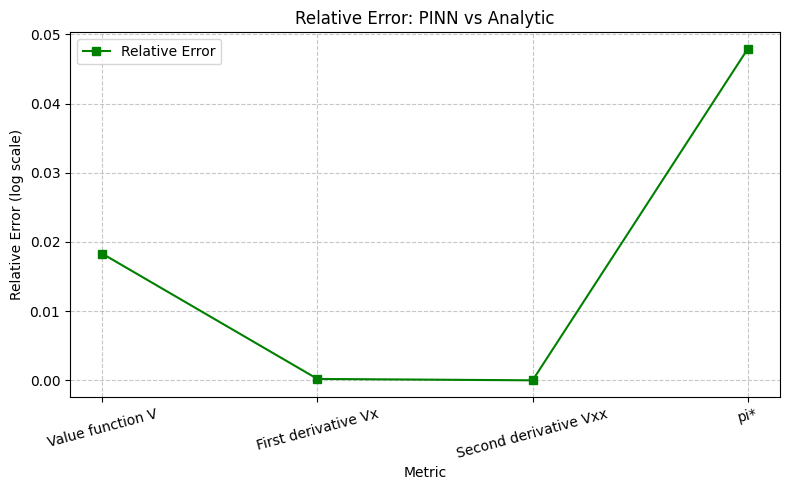

In [ ]:
metrics = metrics_df["Metric"].tolist()
rel_error = metrics_df["Absolute Error"].tolist()
x = range(len(metrics))

plt.figure(figsize=(8,5))
plt.plot(x, rel_error, marker='s', linestyle='-', color='green', label="Relative Error")
plt.xticks(x, metrics, rotation=15)
plt.xlabel("Metric")
plt.ylabel("Relative Error (log scale)")
plt.title("Relative Error: PINN vs Analytic")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Analytics vs PINN

### PINN Performance — via Monte Carlo Simulation
### Analytic Performance — via Closed-Form Merton Solution

In [ ]:
def pi_policy_batch(t, x):
    t_tensor = torch.full((x.shape[0], 1), t, dtype=torch.float32)
    x_tensor = torch.tensor(x.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        pi = pi_net(t_tensor, x_tensor).cpu().numpy().flatten()
    return pi

def simulate_wealth_vectorized(X0=100.0, T=1.0, N_steps=252, N_paths=10000):
    dt = T / N_steps
    X = np.zeros((N_paths, N_steps+1))
    X[:,0] = X0
    for i in range(N_steps):
        t = i * dt
        x_current = X[:,i]
        pi_t = pi_policy_batch(t, x_current)
        dW = np.random.randn(N_paths) * np.sqrt(dt)
        X[:,i+1] = x_current + r*x_current*dt + pi_t*(mu-r)*dt + pi_t*sigma*dW
    return X

X_sim = simulate_wealth_vectorized(X0=X0, T=T, N_steps=252, N_paths=10000)
XT_pinn = X_sim[:,-1]

mean_XT_pinn = np.mean(XT_pinn)
std_XT_pinn = np.std(XT_pinn)
expected_U_pinn = np.mean(-np.exp(-gamma*XT_pinn))
CE_pinn = -np.log(-expected_U_pinn)/gamma
mean_excess_pinn = np.mean(XT_pinn - X0)/T
sharpe_ratio_pinn = mean_excess_pinn / np.std(XT_pinn - X0)

pi_star = (mu - r) / (gamma * sigma**2)
mean_XT_analytic = X0*np.exp(r*T) + pi_star*(mu-r)*T
std_XT_analytic = pi_star*sigma*np.sqrt(T)
expected_U_analytic = -np.exp(-gamma*mean_XT_analytic + 0.5*gamma**2*std_XT_analytic**2)
CE_analytic = mean_XT_analytic - 0.5*gamma*std_XT_analytic**2
mean_excess_analytic = (mean_XT_analytic - X0)/T
sharpe_ratio_analytic = mean_excess_analytic / std_XT_analytic


metrics = pd.DataFrame({
    "Metric": ["Mean Terminal Wealth","Std Dev Terminal Wealth","Expected Utility",
               "Certainty Equivalent (CE)","Mean Excess Return","Sharpe Ratio"],
    "Analytic": [mean_XT_analytic,std_XT_analytic,expected_U_analytic,CE_analytic,
                 mean_excess_analytic,sharpe_ratio_analytic],
    "PINN": [mean_XT_pinn,std_XT_pinn,expected_U_pinn,CE_pinn,
             mean_excess_pinn,sharpe_ratio_pinn]})

metrics["Analytic"] = metrics["Analytic"].apply(lambda x: f"{x:.5f}")
metrics["PINN"] = metrics["PINN"].apply(lambda x: f"{x:.5f}")
metrics

,Metric,Analytic,PINN
0,Mean Terminal Wealth,103.16795,103.17223
1,Std Dev Terminal Wealth,0.35000,0.36718
2,Expected Utility,-0.00000,-0.00000
3,Certainty Equivalent (CE),103.10670,103.10501
4,Mean Excess Return,3.16795,3.17223
5,Sharpe Ratio,9.05130,8.63944


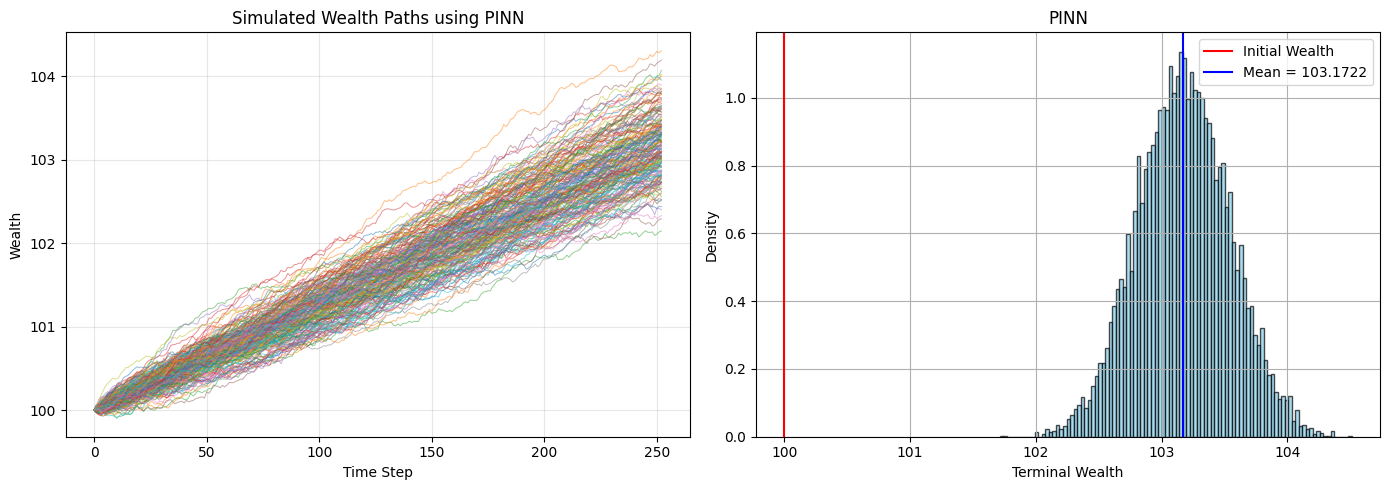

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(min(200, X_sim.shape[0])):
    axes[0].plot(X_sim[i], linewidth=0.7, alpha=0.5)

axes[0].set_title("Simulated Wealth Paths using PINN")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Wealth")
axes[0].grid(True, alpha=0.3)

axes[1].hist(XT_pinn, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='k')
axes[1].axvline(X0, color='r', linestyle='-', label='Initial Wealth')
axes[1].axvline(np.mean(XT_pinn), color='b', linestyle='-', label=f'Mean = {np.mean(XT_pinn):.4f}')
axes[1].set_xlabel('Terminal Wealth')
axes[1].set_ylabel('Density')
axes[1].set_title('PINN')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
XT_pinn

array([103.0880763 , 103.0475579 , 103.41476665, ..., 103.44921467,
       103.10175325, 103.7468112 ])

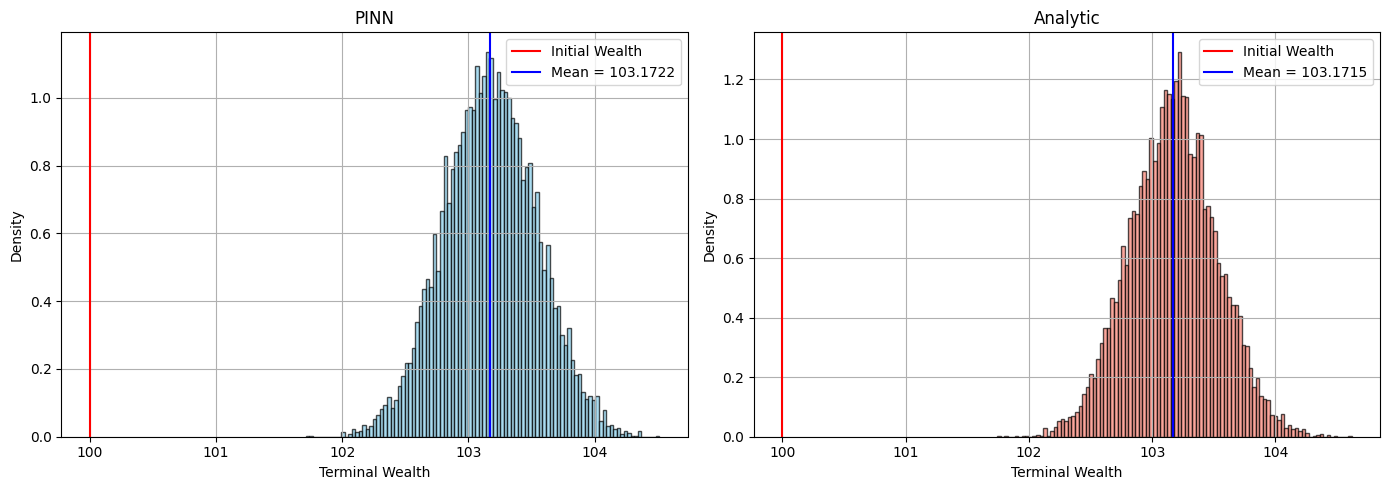

In [ ]:
def simulate_wealth_analytic(X0=100.0, T=1.0, N_steps=252, N_paths=10000, pi_star=pi_star):
    dt = T / N_steps
    X = np.zeros((N_paths, N_steps+1))
    X[:,0] = X0
    for i in range(N_steps):
        dW = np.random.randn(N_paths) * np.sqrt(dt)
        X[:,i+1] = X[:,i] + r*X[:,i]*dt + pi_star*(mu-r)*dt + pi_star*sigma*dW
    return X

X_sim_analytic = simulate_wealth_analytic(X0=X0, N_steps=252, N_paths=10000)
XT_analytic = X_sim_analytic[:,-1]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# PINN
axes[0].hist(XT_pinn, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='k')
axes[0].axvline(X0, color='r', linestyle='-', label='Initial Wealth')
axes[0].axvline(np.mean(XT_pinn), color='b', linestyle='-', label=f'Mean = {np.mean(XT_pinn):.4f}')
axes[0].set_xlabel('Terminal Wealth')
axes[0].set_ylabel('Density')
axes[0].set_title('PINN')
axes[0].legend()
axes[0].grid(True)

# Analytic
axes[1].hist(XT_analytic, bins=100, density=True, alpha=0.7, color='salmon', edgecolor='k')
axes[1].axvline(X0, color='r', linestyle='-', label='Initial Wealth')
axes[1].axvline(np.mean(XT_analytic), color='b', linestyle='-', label=f'Mean = {np.mean(XT_analytic):.4f}')
axes[1].set_xlabel('Terminal Wealth')
axes[1].set_ylabel('Density')
axes[1].set_title('Analytic')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Sensitivity Analysis

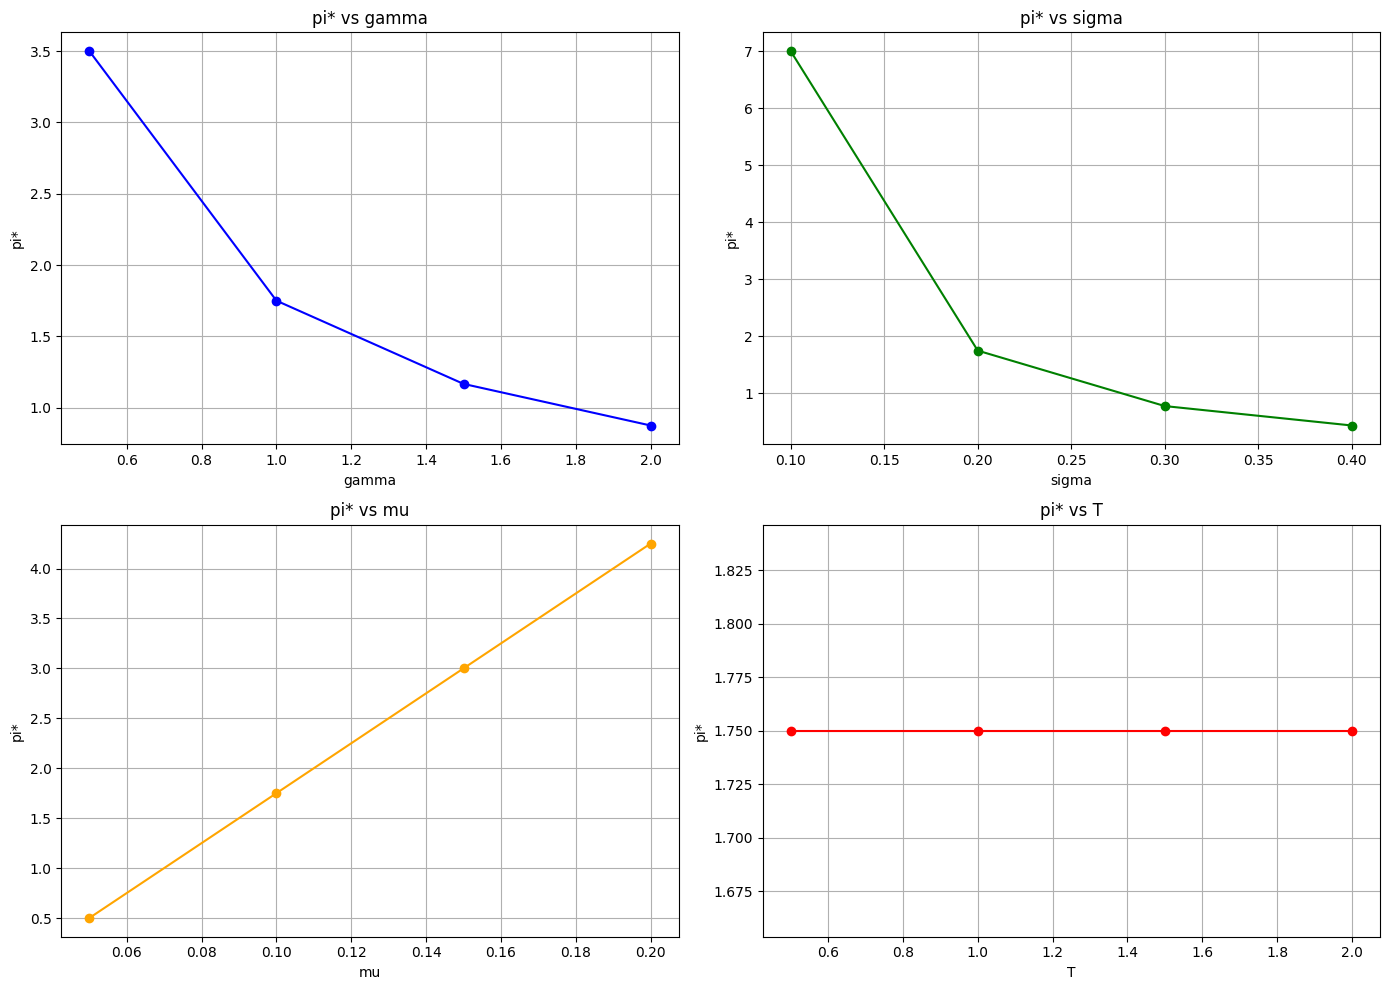

In [ ]:
def pi_star(gamma, mu, r, sigma):
    return (mu - r) / (gamma * sigma**2)

gammas = [0.5, 1.0, 1.5, 2.0]
sigmas = [0.10, 0.20, 0.30, 0.40]
mus = [0.05, 0.10, 0.15, 0.20]
Ts = [0.5, 1.0, 1.5, 2.0]

pi_gamma = [pi_star(g, mu, r, sigma) for g in gammas]
pi_sigma = [pi_star(gamma, mu, r, s) for s in sigmas]
pi_mu = [pi_star(gamma, m, r, sigma) for m in mus]
pi_T = [pi_star(gamma, mu, r, sigma) for T_val in Ts]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes[0,0].plot(gammas, pi_gamma, marker="o", color='blue')
axes[0,0].set_title("pi* vs gamma")
axes[0,0].set_xlabel("gamma")
axes[0,0].set_ylabel("pi*")
axes[0,0].grid(True)
axes[0,1].plot(sigmas, pi_sigma, marker="o", color='green')
axes[0,1].set_title("pi* vs sigma")
axes[0,1].set_xlabel("sigma")
axes[0,1].set_ylabel("pi*")
axes[0,1].grid(True)
axes[1,0].plot(mus, pi_mu, marker="o", color='orange')
axes[1,0].set_title("pi* vs mu")
axes[1,0].set_xlabel("mu")
axes[1,0].set_ylabel("pi*")
axes[1,0].grid(True)
axes[1,1].plot(Ts, pi_T, marker="o", color='red')
axes[1,1].set_title("pi* vs T")
axes[1,1].set_xlabel("T")
axes[1,1].set_ylabel("pi*")
axes[1,1].grid(True)
plt.tight_layout()
plt.show()

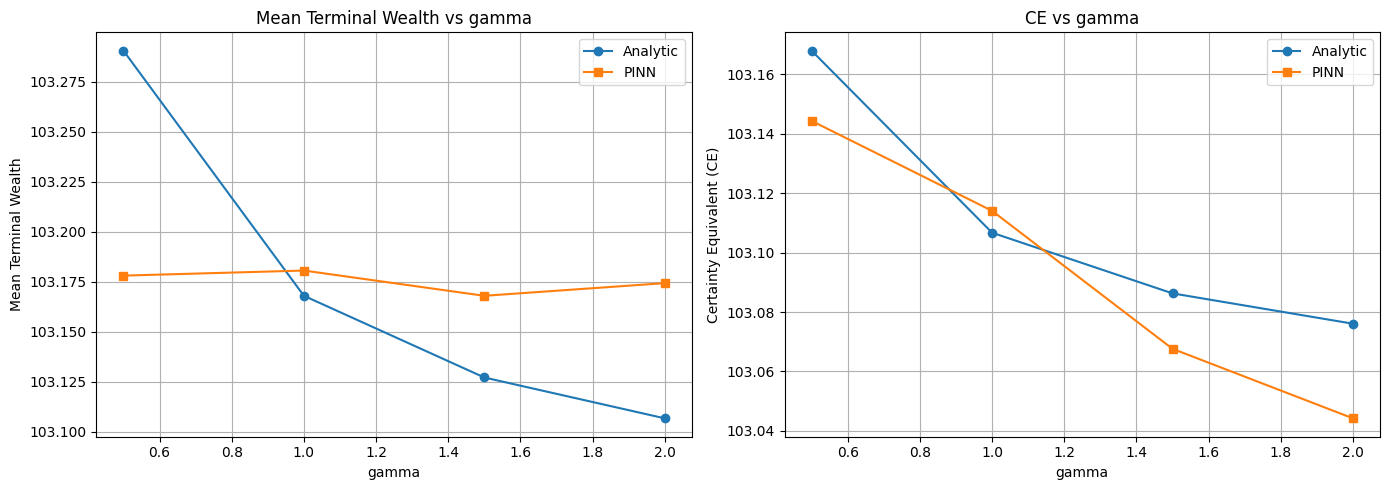

In [ ]:
mu = 0.10
r = 0.03
sigma = 0.20
T = 1.0
X0 = 100
N_paths = 5000
N_steps = 252
gammas = [0.5, 1.0, 1.5, 2.0]

device = torch.device("cpu")

def simulate_pinn_wealth(gamma, X0=100, N_paths=5000, N_steps=252):
    dt = T / N_steps
    X = np.zeros((N_paths, N_steps + 1))
    X[:, 0] = X0

    for i in range(N_steps):
        t = i * dt
        dW = np.random.randn(N_paths) * np.sqrt(dt)
        t_tensor = torch.full((N_paths, 1), t, dtype=torch.float32)
        x_tensor = torch.tensor(X[:, i].reshape(-1,1), dtype=torch.float32)
        with torch.no_grad():
            pi_vals = pi_net(t_tensor, x_tensor).numpy().flatten()

        X[:, i+1] = X[:, i] + r*X[:, i]*dt + pi_vals*(mu-r)*dt + pi_vals*sigma*dW

    return X[:, -1]

def analytic_mean_XT(gamma):
    pi_star = (mu - r) / (gamma * sigma**2)
    return X0*np.exp(r*T) + pi_star*(mu-r)*T

def analytic_CE(gamma):
    pi_star = (mu - r) / (gamma * sigma**2)
    mean = analytic_mean_XT(gamma)
    std = pi_star*sigma*np.sqrt(T)
    return mean - 0.5*gamma*std**2

mean_pinn_list = []
mean_analytic_list = []
CE_pinn_list = []
CE_analytic_list = []

for gamma in gammas:
    XT = simulate_pinn_wealth(gamma)
    mean_pinn = np.mean(XT)
    mean_pinn_list.append(mean_pinn)
    expected_U = np.mean(-np.exp(-gamma*XT))
    CE_pinn = -np.log(-expected_U) / gamma
    CE_pinn_list.append(CE_pinn)

    mean_analytic = analytic_mean_XT(gamma)
    CE_analytic = analytic_CE(gamma)
    mean_analytic_list.append(mean_analytic)
    CE_analytic_list.append(CE_analytic)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(gammas, mean_analytic_list, marker='o', label="Analytic")
axes[0].plot(gammas, mean_pinn_list, marker='s', label="PINN")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Mean Terminal Wealth")
axes[0].set_title("Mean Terminal Wealth vs gamma")
axes[0].grid(True)
axes[0].legend()
axes[1].plot(gammas, CE_analytic_list, marker='o', label="Analytic")
axes[1].plot(gammas, CE_pinn_list, marker='s', label="PINN")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("Certainty Equivalent (CE)")
axes[1].set_title("CE vs gamma")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Without Pi regularization

In [ ]:
x_min = 0 #50.0
x_max = 500 #150.0

def grad(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),create_graph=True, retain_graph=True)[0]

class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1, nlayers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        for _ in range(nlayers - 1):
            layers.append(nn.Tanh())
            layers.append(nn.Linear(hidden, hidden))
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, t, x):
        tt = t / T
        xx = (x - (x_min + x_max) / 2.0) / (x_max - x_min)
        inp = torch.cat([tt, xx], dim=1)
        return self.net(inp)

V_net = MLP()
pi_net = MLP()

N_f = 5000 #3000
N_T = 300
N_b = 200
lr = 5e-4
epochs = 6000
optimizer = optim.Adam(list(V_net.parameters()) + list(pi_net.parameters()),lr=lr)
w_pde = 1.0
w_term = 200.0
w_bc = 10.0
w_pi_reg = 1e-4 #1e-3
x_T = torch.linspace(x_min, x_max, N_T).unsqueeze(1)
t_T = torch.ones_like(x_T) * T
loss_history = []

for it in range(epochs):
    V_net.train()
    pi_net.train()

    optimizer.zero_grad()

    # interior points
    t_f = torch.rand(N_f, 1) * T
    x_f = x_min + (x_max - x_min) * torch.rand(N_f, 1)
    t_f.requires_grad_(True)
    x_f.requires_grad_(True)

    # forward pass
    V_f = V_net(t_f, x_f)
    pi_f = pi_net(t_f, x_f)

    # derivatives
    V_t = grad(V_f, t_f)
    V_x = grad(V_f, x_f)
    V_xx = grad(V_x, x_f)

    # PDE
    pde_res = V_t + r * x_f * V_x + pi_f * (mu - r) * V_x \
              + 0.5 * (pi_f**2) * sigma**2 * V_xx
    loss_pde = torch.mean(pde_res**2)

    # terminal
    x_Tb = x_T.clone().detach().requires_grad_(True)
    t_Tb = t_T.clone().detach().requires_grad_(True)
    V_T_pred = V_net(t_Tb, x_Tb)
    V_T_true = -torch.exp(-gamma * x_Tb)
    loss_term = torch.mean((V_T_pred - V_T_true)**2)

    # boundary soft anchoring
    t_b = torch.rand(N_b, 1) * T
    x_b_left = torch.ones_like(t_b) * x_min
    x_b_right = torch.ones_like(t_b) * x_max
    V_b_left = V_net(t_b, x_b_left)
    V_b_right = V_net(t_b, x_b_right)
    V_b_left_target  = -torch.exp(-gamma * x_b_left)
    V_b_right_target = -torch.exp(-gamma * x_b_right)

    loss_bc = torch.mean((V_b_left  - V_b_left_target )**2) + \
              torch.mean((V_b_right - V_b_right_target)**2)

    # pi regularizer
    loss_pi_reg = torch.mean((pi_f - pi_star_analytic)**2)

    # total loss
    #loss = (w_pde * loss_pde +w_term * loss_term + w_bc * loss_bc + w_pi_reg * loss_pi_reg)
    loss = (w_pde * loss_pde +w_term * loss_term + w_bc * loss_bc)

    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (it+1) % 200 == 0 or it == 0:
        # monitoring at (t=0,x=100)
        t_test = torch.tensor([[0.0]], requires_grad=True)
        x_test = torch.tensor([[100.0]], requires_grad=True)
        Vt = V_net(t_test, x_test)
        pit = pi_net(t_test, x_test)
        print(f"iter {it+1:5d} loss={loss.item():.3e} "
              f"pde={loss_pde.item():.3e} term={loss_term.item():.3e} "
              f"pi(0,100)={pit.item():.4f} " f"V(0,100)={Vt.item():.4f}")

iter     1 loss=1.357e+01 pde=3.534e-03 term=9.765e-03 pi(0,100)=-0.0764 V(0,100)=0.0465
iter   200 loss=2.975e+00 pde=4.695e-01 term=5.207e-03 pi(0,100)=-18.1184 V(0,100)=-0.9556
iter   400 loss=2.202e+00 pde=4.544e-01 term=4.375e-03 pi(0,100)=-26.7979 V(0,100)=-0.8378
iter   600 loss=1.870e+00 pde=4.230e-01 term=3.990e-03 pi(0,100)=-35.4519 V(0,100)=-0.8355
iter   800 loss=1.611e+00 pde=3.625e-01 term=3.375e-03 pi(0,100)=-44.1496 V(0,100)=-0.7830
iter  1000 loss=1.259e+00 pde=2.511e-01 term=3.319e-03 pi(0,100)=-52.9206 V(0,100)=-0.5887
iter  1200 loss=1.061e+00 pde=1.970e-01 term=2.767e-03 pi(0,100)=-61.5583 V(0,100)=-0.1785
iter  1400 loss=8.905e-01 pde=1.571e-01 term=2.617e-03 pi(0,100)=-70.0933 V(0,100)=0.1208
iter  1600 loss=8.280e-01 pde=1.192e-01 term=2.426e-03 pi(0,100)=-78.2450 V(0,100)=0.1468
iter  1800 loss=6.722e-01 pde=8.524e-02 term=2.067e-03 pi(0,100)=-85.6223 V(0,100)=0.0935
iter  2000 loss=6.207e-01 pde=6.461e-02 term=2.172e-03 pi(0,100)=-91.6654 V(0,100)=0.0650
iter 

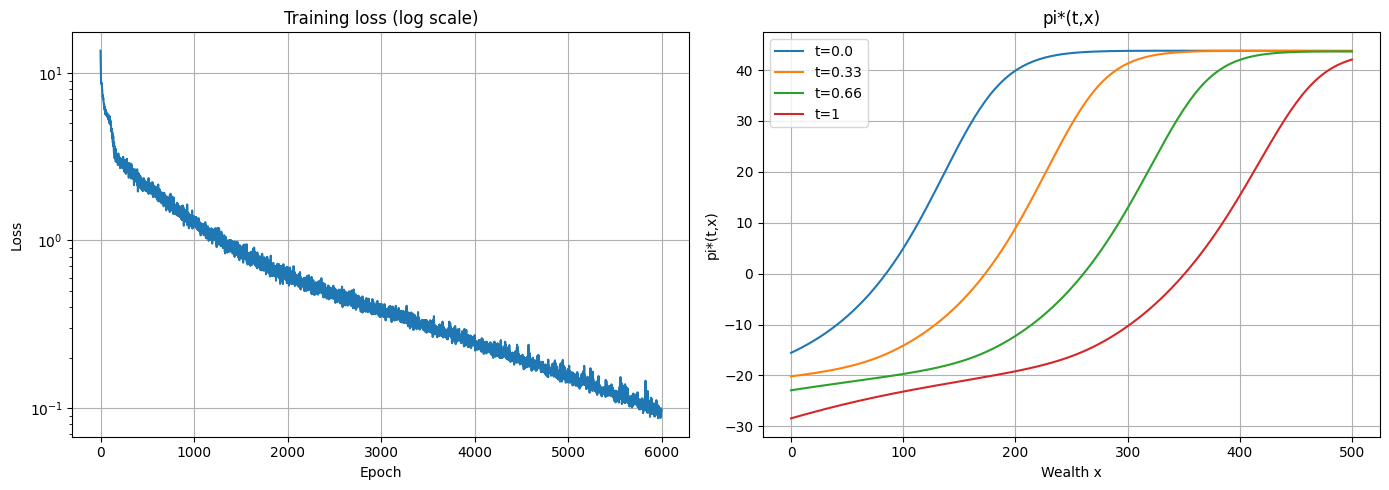

In [ ]:
x_grid = np.linspace(x_min, x_max, 200)
x_t = torch.tensor(x_grid.reshape(-1,1), dtype=torch.float32)


fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(loss_history)
axes[0].set_yscale('log')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss (log scale)")
axes[0].grid(True)

t_slices = [0.0, 0.33, 0.66,1]
for ts in t_slices:
    t_vec = torch.full_like(x_t, ts)
    with torch.no_grad():
        pi_ts = pi_net(t_vec, x_t).numpy().flatten()
    axes[1].plot(x_grid, pi_ts, label=f"t={ts}")

axes[1].set_xlabel("Wealth x")
axes[1].set_ylabel("pi*(t,x)")
axes[1].set_title("pi*(t,x)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

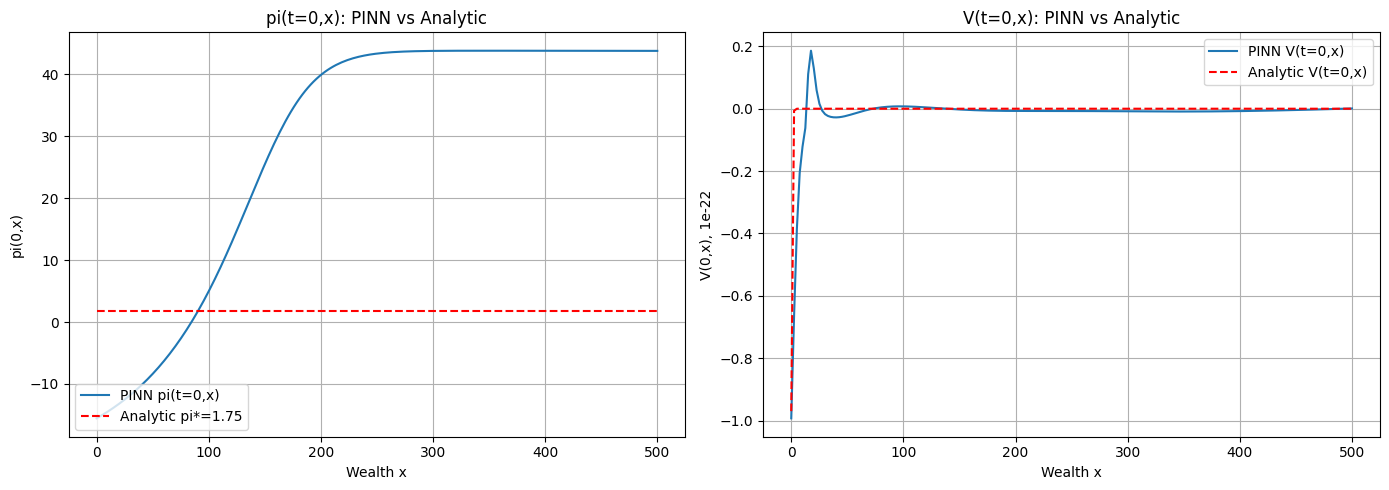

In [ ]:
t0 = torch.zeros_like(x_t)

with torch.no_grad():
    pi_pred = pi_net(t0, x_t).numpy().flatten()
    V_pred = V_net(t0, x_t).numpy().flatten()

V0_analytic = V_analytic(0, x_grid)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(x_grid, pi_pred, label="PINN pi(t=0,x)")
axes[0].hlines(pi_star_analytic, x_grid[0], x_grid[-1], colors="k", linestyles="--",color='red',label=f"Analytic pi*={pi_star_analytic:.2f}")
axes[0].set_xlabel("Wealth x")
axes[0].set_ylabel("pi(0,x)")
axes[0].set_title("pi(t=0,x): PINN vs Analytic")
axes[0].legend(loc='lower left')
axes[0].grid(True)

axes[1].plot(x_grid, V_pred, label="PINN V(t=0,x)")
axes[1].plot(x_grid, V0_analytic, "--", label="Analytic V(t=0,x)",color='red')
axes[1].set_xlabel("Wealth x")
axes[1].set_ylabel("V(0,x), 1e-22")
axes[1].set_title("V(t=0,x): PINN vs Analytic")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()